##Binary Classification
Context:
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

Task:
To predict which customer is more likely to purchase the newly introduced travel package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


Data Cleaning

1.Handle missing values
2.Handle duplicates
3.Check data type
4.Understand dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [4]:
#Check all categories
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [5]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [6]:
df['TypeofContact'].value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [7]:
df['Designation'].value_counts()

,count
Designation,
Executive,1842
Manager,1732
Senior Manager,742
AVP,342
VP,230


So here MaritalStatus and Gender has incorrect spellings

In [8]:
df['Gender'] = df['Gender'].replace('Fe Male','Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')

In [9]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Unmarried,1598
Divorced,950


In [10]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [11]:
#Checking Missing values(NaN)
features_with_na = [features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5),'% missing values')

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [13]:
#Statistics on numerical columns from the cols with null values
df[features_with_na].select_dtypes(exclude='object').describe()   #selects any data type but excludes object type

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [17]:
#Handling missing values by replacing them with their mode or medians
#For categorical features --- mode
#For numerical values --- median
df['Age'].fillna(df['Age'].median(),inplace=True)
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0],inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(),inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0],inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0],inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)

In [18]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0


In [19]:
#Removing customer id
df.drop('CustomerID',axis=1,inplace=True)

Feature Engineering

In [20]:
#Combining 2 features --- NumberOfChildrenVisiting + NumberOfPersonVisiting

df['TotalVisiting'] = df['NumberOfChildrenVisiting'] + df['NumberOfPersonVisiting']
df.drop(['NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)

In [21]:
#Get the no. of numerical features
numerical_features = [feature for feature in df.columns if df[feature].dtype!='O']
print('Number of numerical features:',len(numerical_features))

Number of numerical features: 12


In [ ]:
numerical_features

['ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'MonthlyIncome',
 'TotalVisiting']

In [22]:
#Get no. of categorical features

categorical_features = [feature for feature in df.columns if df[feature].dtype=='O']
print('Number of categorical features:',len(categorical_features))

Number of categorical features: 6


In [24]:
#Get no. of Discrete features --- columns that hv atleast 10-25 categories

discrete_features = [feature for feature in numerical_features if len(df[feature].unique())<=25]
print('Number of discrete features:',len(discrete_features))

Number of discrete features: 9


In [25]:
for feature in numerical_features:
   print(len(df[feature].unique()))

2
44
3
34
6
3
12
2
5
2
2475
7


In [26]:
#Get no. of Continuous features

continuous_features = [feature for feature in numerical_features if feature not in discrete_features]
print('Number of continuous features:',len(continuous_features))

Number of continuous features: 3


Model Training

In [40]:
#Splitting input and target feature

X = df.drop('ProdTaken',axis=1)
y = df['ProdTaken']     #target feature is wether new product is taken or not


In [29]:
X,y

(       Age    TypeofContact  CityTier  DurationOfPitch      Occupation  \
 0     41.0     Self Enquiry         3              6.0        Salaried   
 1     49.0  Company Invited         1             14.0        Salaried   
 2     37.0     Self Enquiry         1              8.0     Free Lancer   
 3     33.0  Company Invited         1              9.0        Salaried   
 4     36.0     Self Enquiry         1              8.0  Small Business   
 ...    ...              ...       ...              ...             ...   
 4883  49.0     Self Enquiry         3              9.0  Small Business   
 4884  28.0  Company Invited         1             31.0        Salaried   
 4885  52.0     Self Enquiry         3             17.0        Salaried   
 4886  19.0     Self Enquiry         3             16.0  Small Business   
 4887  36.0     Self Enquiry         1             14.0        Salaried   
 
       Gender  NumberOfFollowups ProductPitched  PreferredPropertyStar  \
 0     Female           

In [41]:
#train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Engineering--part 2

Encoding Categorical features

In [31]:
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

print(cat_features)

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')


In [32]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [37]:
#Create column Transformer wid 3 types of transformers

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#ColumnTransformer combines multiple kinds of transformations together
#OneHotEncoding Categorical features and Standardizing Numerical features

transformer = ColumnTransformer(
    transformers=[
    ('encoder',OneHotEncoder(drop='first'),cat_features),
    ('scaler',StandardScaler(),num_features)])

In [38]:
transformer

ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('scaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [42]:
#Applying transformation in train and test data

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [36]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [51]:
#Random Forest Classifier Training

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score,roc_auc_score

In [52]:
#creating a dictionary of different models
models = {
    "Logistic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier()  #taking default model
}
for val in models.values():
  model = val
  model.fit(X_train,y_train)

  #Model predictions
  y_test_pred = model.predict(X_test)
  y_train_pred = model.predict(X_train)

  #Model Evaluation on Training data
  print("\n",model)
  print("Training data Performance:")
  print(accuracy_score(y_train,y_train_pred))
  print(f1_score(y_train,y_train_pred))
  print(precision_score(y_train,y_train_pred))
  print(recall_score(y_train,y_train_pred))
  print(roc_auc_score(y_train,y_train_pred))
  print(confusion_matrix(y_train,y_train_pred))


  #Model evaluation on Test data
  print("\nTest data Performance:")
  print(accuracy_score(y_test,y_test_pred))
  print(f1_score(y_test,y_test_pred))
  print(precision_score(y_test,y_test_pred))
  print(recall_score(y_test,y_test_pred))
  print(roc_auc_score(y_test,y_test_pred))
  print(confusion_matrix(y_test,y_test_pred))



 LogisticRegression()
Training data Performance:
0.8460358056265984
0.42337164750957856
0.7015873015873015
0.30315500685871055
0.6368022755136056
[[3087   94]
 [ 508  221]]

Test data Performance:
0.83640081799591
0.4117647058823529
0.691358024691358
0.2931937172774869
0.630713758257549
[[762  25]
 [135  56]]

 DecisionTreeClassifier()
Training data Performance:
1.0
1.0
1.0
1.0
1.0
[[3181    0]
 [   0  729]]

Test data Performance:
0.9161554192229039
0.7807486631016043
0.7978142076502732
0.7643979057591623
0.8586919643154134
[[750  37]
 [ 45 146]]

 RandomForestClassifier()
Training data Performance:
1.0
1.0
1.0
1.0
1.0
[[3181    0]
 [   0  729]]

Test data Performance:
0.9253578732106339
0.7697160883280757
0.9682539682539683
0.6387434554973822
0.8168304316877
[[783   4]
 [ 69 122]]


So Random Forest has given the best test performance, so we r gonna hyperParameter tune randomForest Classifier only.

HyperParameter Tuning

In [53]:
params = {
    'max_depth':[5,8,15,10,None],
    'min_samples_split':[2,8,15,20],
    'max_features':[5,7,'auto',8],
    'n_estimators':[100,200,500,1000]
}

In [54]:
randomcv = [('RF',RandomForestClassifier(),params)]

In [55]:
#RandomSearchCV

from sklearn.model_selection import RandomizedSearchCV
model_param = {}
for name,model,params in randomcv:
  random = RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=100,cv=3,verbose=2,n_jobs=-1)
  random.fit(X_train,y_train)

  model_param[name] = random.best_params_

for model_name in model_param:
  print(f"Best parameters for {model_name} are {model_param[model_name]}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters for RF are {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [56]:
models = {
    "Random Forest":RandomForestClassifier(n_estimators=500,min_samples_split=2,max_features=7,max_depth=None)  #taking the best parameters for tuning
}
for val in models.values():
  model = val
  model.fit(X_train,y_train)

  #Model predictions
  y_test_pred = model.predict(X_test)
  y_train_pred = model.predict(X_train)

  #Model Evaluation on Training data
  print("\n",model)
  print("Training data Performance:")
  print(accuracy_score(y_train,y_train_pred))
  print(f1_score(y_train,y_train_pred,average='weighted'))
  print(precision_score(y_train,y_train_pred))
  print(recall_score(y_train,y_train_pred))
  print(roc_auc_score(y_train,y_train_pred))
  print(confusion_matrix(y_train,y_train_pred))


  #Model evaluation on Test data
  print("\nTest data Performance:")
  print(accuracy_score(y_test,y_test_pred))
  print(f1_score(y_test,y_test_pred,average='weighted'))
  print(precision_score(y_test,y_test_pred))
  print(recall_score(y_test,y_test_pred))
  print(roc_auc_score(y_test,y_test_pred))
  print(confusion_matrix(y_test,y_test_pred))


 RandomForestClassifier(max_features=7, n_estimators=500)
Training data Performance:
1.0
1.0
1.0
1.0
1.0
[[3181    0]
 [   0  729]]

Test data Performance:
0.9304703476482618
0.9254825292231563
0.9624060150375939
0.6701570680628273
0.8319019139551748
[[782   5]
 [ 63 128]]


So,we find that after HyperParameter tuning, the Recall score has improved from 63% to 67%

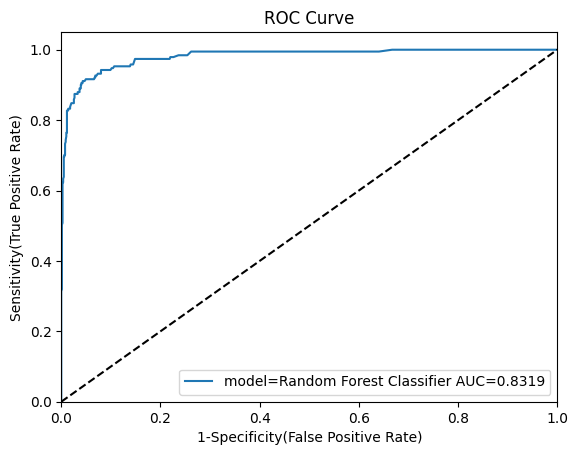

In [62]:
#Plot ROC-AUC curve

from sklearn.metrics import roc_curve,roc_auc_score
plt.figure()

#Listing the models that we want to view on roc curve

auc_models = [
    {
        'label':'Random Forest Classifier',
        'model':RandomForestClassifier(n_estimators=500,min_samples_split=2,max_features=7,max_depth=None),
        'auc':0.8319
    }
]

#Create loop thru all models
for algo in auc_models:
  model = algo['model']
  model.fit(X_train,y_train)

  y_pred_prob = model.predict_proba(X_test)[:,1]    #finds the prob of occurence of 1 in output for given test data

  #Calculate ROC curve
  fpr,tpr,thresholds = roc_curve(y_test,y_pred_prob)

  #Plotting the curve with a label which prints area under curve of RandomForest
  plt.plot(fpr,tpr,label=f'model={algo["label"]} AUC={algo["auc"]}')
#Custom settings for the plot
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')    #FPR = 1 - Specificity
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig('roc_curve.png')
plt.show()

Here we can see that most of the area is under the curve of Random Forest Classifier